In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import DenseGCNConv
from torch_geometric.utils import to_dense_batch
import matplotlib.pyplot as plt
import seaborn as sns

/home/filipe-silva/redes_grafos/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = pd.read_csv('data.csv',delimiter=';')

<Figure size 600x500 with 0 Axes>

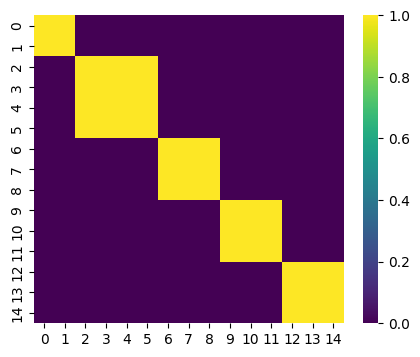

In [ ]:
step_0 = data[(data['scene'] == 0) & (data['step'] == 0)].sort_values('sensor')

robots = step_0['robot'].values 
adj_real = np.zeros((15, 15))

for i in range(15):
    for j in range(15):
        if robots[i] == robots[j]:
            adj_real[i, j] = 1.0

plt.figure(figsize=(5, 4))
sns.heatmap(adj_real, cmap="viridis", vmin=0, vmax=1)
plt.show()

In [5]:
lista_de_grafos = []

for scene_id in data['scene'].unique():
    scene_data = data[data['scene'] == scene_id]
    
    for step_id in scene_data['step'].unique():
        step_data = scene_data[scene_data['step'] == step_id].sort_values('sensor')
        
        x = torch.tensor(step_data[['measure_x', 'measure_y']].values, dtype=torch.float)
        
        y = torch.tensor(step_data[['robot_x', 'robot_y']].values, dtype=torch.float)
        
        grafo = Data(x=x, y=y, scene=scene_id)
        lista_de_grafos.append(grafo)

In [6]:
train_dataset = [g for g in lista_de_grafos if g.scene < 12]

val_dataset = [g for g in lista_de_grafos if 12 <= g.scene < 16]

test_dataset = [g for g in lista_de_grafos if g.scene >= 16]

print(f"Grafos no Treino: {len(train_dataset)}")
print(f"Grafos na Validação: {len(val_dataset)}")
print(f"Grafos no Teste Final: {len(test_dataset)}")

Grafos no Treino: 240
Grafos na Validação: 80
Grafos no Teste Final: 80


In [7]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
from torch_geometric.nn import DenseGCNConv
from torch.nn import Linear
import torch.nn as nn
import torch.nn.functional as F

class DenseGCN(torch.nn.Module):
    def __init__(self, adj):
        super().__init__()
        
        self.adj_param = nn.Parameter(adj.clone().float())

        self.gcn1 = DenseGCNConv(2, 64) 
        self.gcn2 = DenseGCNConv(64, 2)

    def normalize_adj(self, adj):
        eye = torch.eye(adj.size(-1), device=adj.device).unsqueeze(0)
        adj_hat = adj + eye
        deg = adj_hat.sum(dim=-1)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt.masked_fill_(deg_inv_sqrt == float('inf'), 0)
        return deg_inv_sqrt.unsqueeze(-1) * adj_hat * deg_inv_sqrt.unsqueeze(1)
    
    def forward(self, x):
        # adj_positive = F.sigmoid(self.adj_param)
        adj_positive = F.sigmoid(self.adj_param) # F.softmax(self.adj_param, dim=-1)
        # adj_positive = gumbel_sigmoid(self.adj_param)
        
        adj_norm = self.normalize_adj(adj_positive)
        
        x = self.gcn1(x, adj_norm, add_loop=False)
        x = F.relu(x)
        x = F.dropout(x, p=0.1, training=self.training)
        x = self.gcn2(x, adj_norm, add_loop=False)
        
        return x


adj = torch.rand((15,15)) * 0.04 + 0.01
plt.figure(figsize=(5, 4))
sns.heatmap(adj, cmap="viridis", vmin=0, vmax=1)
plt.show()
adj = adj.unsqueeze(0)  
model = DenseGCN(adj)
print(model)
for name, param in model.named_parameters():
    print(f"Camada: {name}")
    print(f"Tamanho (Shape): {param.shape}")
    print(f"Valores:\n{param}\n")

DenseGCN(
  (gcn1): DenseGCNConv(2, 64)
  (gcn2): DenseGCNConv(64, 2)
)
Camada: adj_param
Tamanho (Shape): torch.Size([1, 15, 15])
Valores:
Parameter containing:
tensor([[[0.0229, 0.0475, 0.0386, 0.0108, 0.0229, 0.0475, 0.0174, 0.0394,
          0.0115, 0.0107, 0.0496, 0.0370, 0.0258, 0.0493, 0.0172],
         [0.0123, 0.0462, 0.0367, 0.0471, 0.0195, 0.0353, 0.0321, 0.0433,
          0.0405, 0.0220, 0.0176, 0.0329, 0.0232, 0.0225, 0.0272],
         [0.0421, 0.0232, 0.0304, 0.0424, 0.0228, 0.0360, 0.0296, 0.0419,
          0.0464, 0.0421, 0.0429, 0.0111, 0.0104, 0.0316, 0.0306],
         [0.0123, 0.0389, 0.0282, 0.0215, 0.0192, 0.0254, 0.0229, 0.0123,
          0.0254, 0.0444, 0.0360, 0.0268, 0.0105, 0.0409, 0.0218],
         [0.0273, 0.0219, 0.0338, 0.0183, 0.0271, 0.0171, 0.0294, 0.0141,
          0.0172, 0.0384, 0.0425, 0.0229, 0.0147, 0.0478, 0.0467],
         [0.0226, 0.0347, 0.0314, 0.0433, 0.0274, 0.0441, 0.0304, 0.0223,
          0.0425, 0.0274, 0.0236, 0.0240, 0.0244, 0.0470, 0

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for data in loader:
        data = data.to(device)
     
        batch_size = data.num_graphs
        x_dense = data.x.view(batch_size, 15, 2)
        y_dense = data.y.view(batch_size, 15, 2)
        
        optimizer.zero_grad()
        
        out = model(x_dense)
        
        loss = criterion(out, y_dense)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_size
        
    return total_loss / len(loader.dataset)

@torch.no_grad() 
def test_epoch(model, loader, criterion):
    model.eval()
    total_mse = 0
    total_mae = 0
    
    for data in loader:
        data = data.to(device)
        
        batch_size = data.num_graphs
        x_dense = data.x.view(batch_size, 15, 2)
        y_dense = data.y.view(batch_size, 15, 2)
        
        out = model(x_dense)
        
        loss = criterion(out, y_dense)
        total_mse += loss.item() * batch_size
        
        mae = F.l1_loss(out, y_dense)
        total_mae += mae.item() * batch_size
        
    return total_mse / len(loader.dataset), total_mae / len(loader.dataset)

Epoch   1 | Train MSE: 148401.26 | Validation MSE: 112101.15 | Validation MAE: 273.79


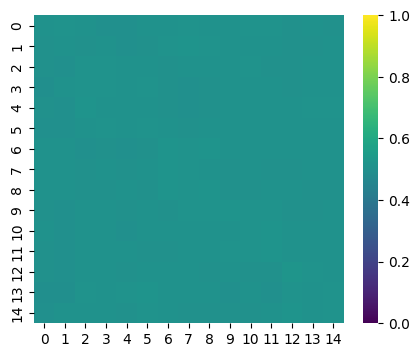

Epoch  20 | Train MSE: 72328.64 | Validation MSE: 77974.24 | Validation MAE: 201.56


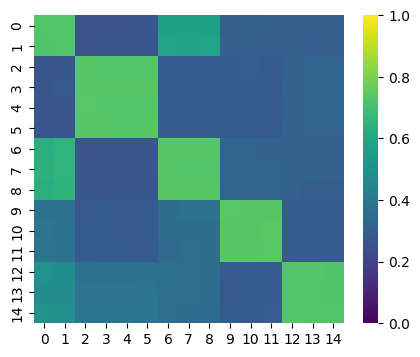

Epoch  40 | Train MSE: 27490.51 | Validation MSE: 40580.13 | Validation MAE: 154.35


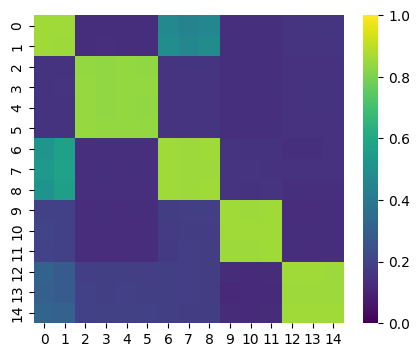

Epoch  60 | Train MSE: 11476.88 | Validation MSE: 19820.44 | Validation MAE: 113.39


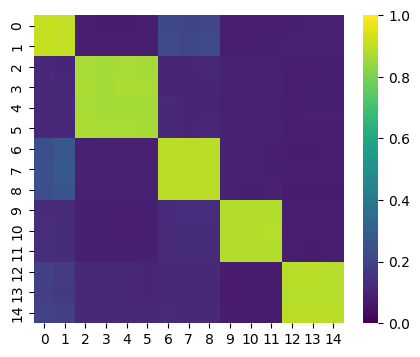

Epoch  80 | Train MSE: 6040.35 | Validation MSE: 10414.33 | Validation MAE: 82.19


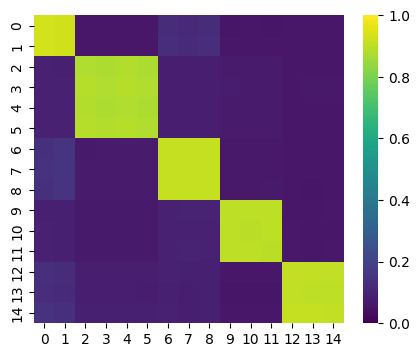

Epoch 100 | Train MSE: 3780.47 | Validation MSE: 6962.39 | Validation MAE: 67.44


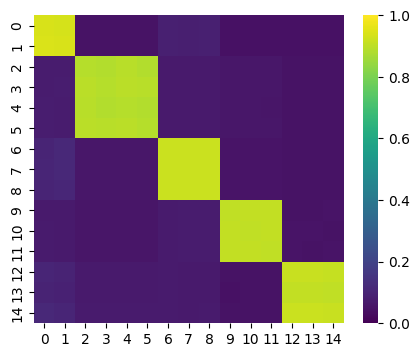

Epoch 120 | Train MSE: 2694.44 | Validation MSE: 4416.24 | Validation MAE: 52.24


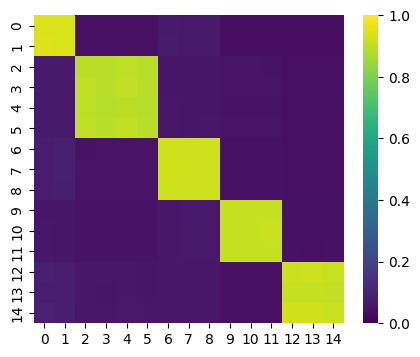

Epoch 140 | Train MSE: 1960.43 | Validation MSE: 3206.83 | Validation MAE: 44.87


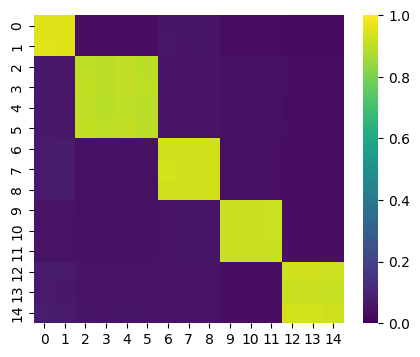

Epoch 160 | Train MSE: 1626.12 | Validation MSE: 2551.14 | Validation MAE: 39.80


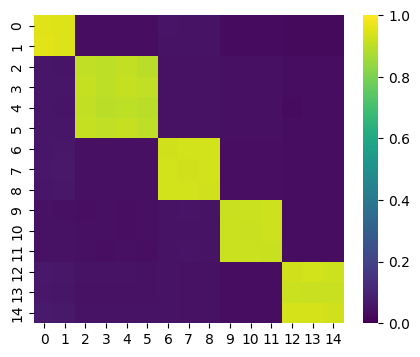

Epoch 180 | Train MSE: 1298.06 | Validation MSE: 2489.17 | Validation MAE: 39.20


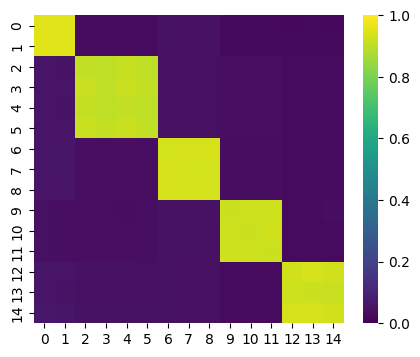

Epoch 200 | Train MSE: 1106.42 | Validation MSE: 1600.22 | Validation MAE: 30.65


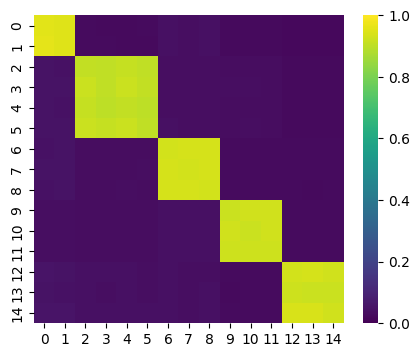

Epoch 220 | Train MSE: 1036.85 | Validation MSE: 1437.51 | Validation MAE: 28.92


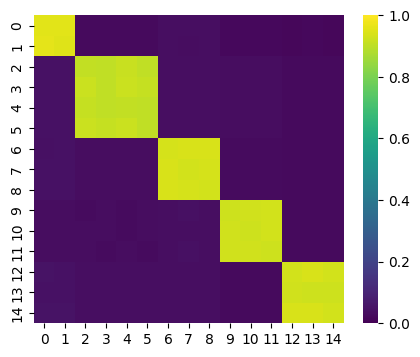

Epoch 240 | Train MSE: 970.21 | Validation MSE: 1456.45 | Validation MAE: 29.37


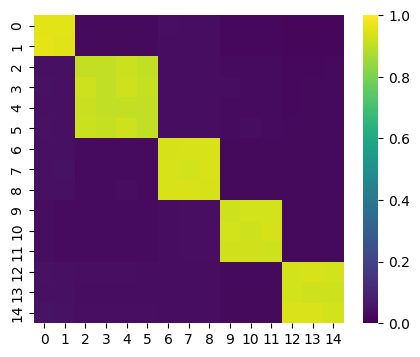

Epoch 260 | Train MSE: 849.00 | Validation MSE: 1097.66 | Validation MAE: 25.16


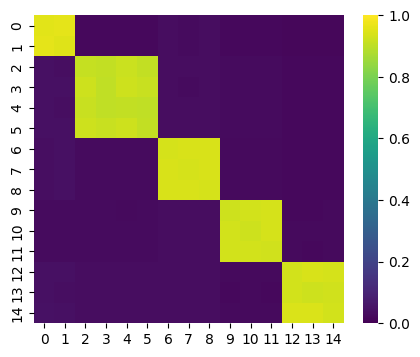

Epoch 280 | Train MSE: 813.62 | Validation MSE: 1273.69 | Validation MAE: 28.11


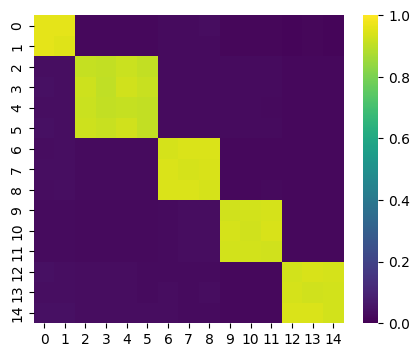

Epoch 300 | Train MSE: 770.03 | Validation MSE: 746.31 | Validation MAE: 20.71


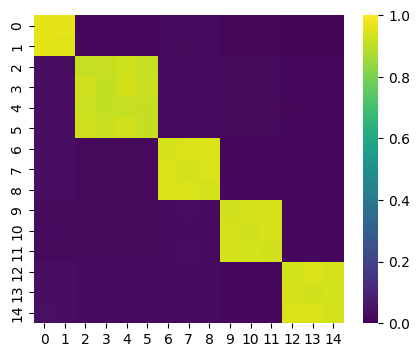

Epoch 320 | Train MSE: 728.59 | Validation MSE: 938.21 | Validation MAE: 23.86


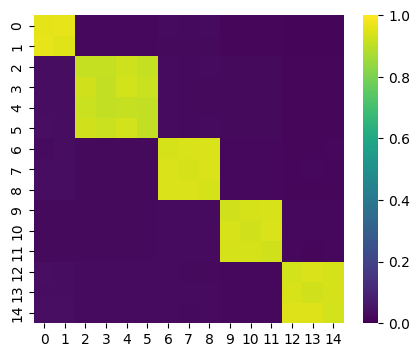

Epoch 340 | Train MSE: 692.51 | Validation MSE: 911.34 | Validation MAE: 23.47


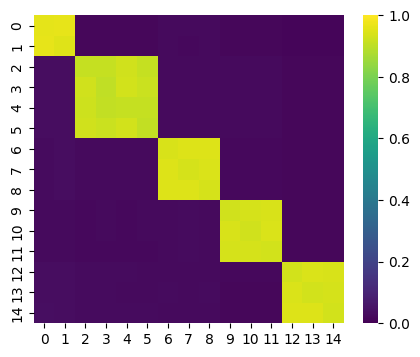


Best Epoch: 327 Validation MAE: 18.81


<All keys matched successfully>

In [26]:
model_dgcn = DenseGCN(adj).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model_dgcn.parameters(), lr=0.005)

train_losses = []
val_losses = []
best_val_mae = float('inf')
best_weights = None
best_epoch = 0


for epoch in range(1, 351):
    
    loss = train_epoch(model_dgcn, train_loader, optimizer, criterion)
    train_losses.append(loss)

    val_mse, val_mae = test_epoch(model_dgcn, val_loader, criterion)
    val_losses.append(val_mse)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch = epoch
        best_weights = model_dgcn.state_dict().copy()
        
    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3} | Train MSE: {loss:.2f} | Validation MSE: {val_mse:.2f} | Validation MAE: {val_mae:.2f}')
        
        adj_now = torch.sigmoid(model_dgcn.adj_param).detach().cpu().numpy()
        
        plt.figure(figsize=(5, 4))
        sns.heatmap(adj_now.squeeze(0), cmap="viridis", vmin=0, vmax=1)
        plt.show()


print(f"\nBest Epoch: {best_epoch} Validation MAE: {best_val_mae:.2f}")
model_dgcn.load_state_dict(best_weights)


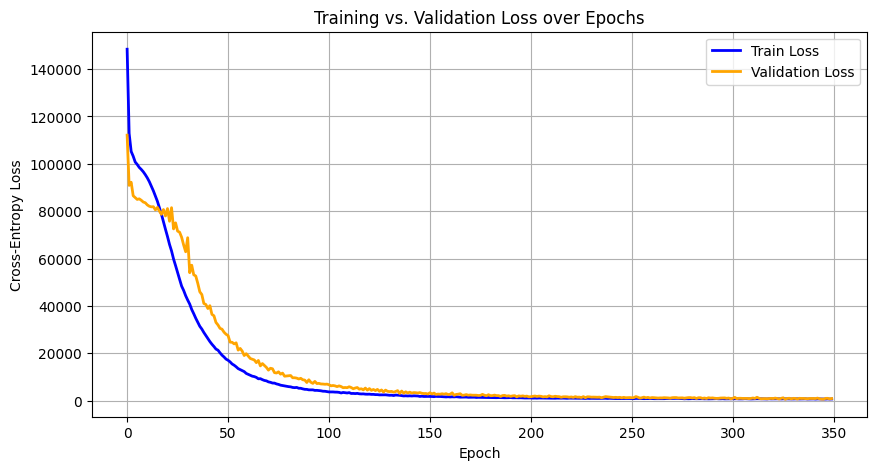

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training vs. Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
test_mse_final, test_mae_final = test_epoch(model_dgcn, test_loader, criterion)

print(f"MAE: {test_mae_final:.2f}")

MAE: 26.94


[[[0.9587886  0.96309924 0.01906917 0.01855604 0.01861407 0.01882569
   0.02635648 0.02452889 0.0265688  0.01609405 0.0165253  0.015899
   0.01260533 0.01280847 0.01228905]
  [0.9619862  0.95196056 0.01883395 0.0187023  0.01848455 0.01847572
   0.02451041 0.02268824 0.02464226 0.01613482 0.01617939 0.01582038
   0.01246029 0.01254328 0.01229693]
  [0.03258692 0.03081476 0.9128086  0.9138354  0.9271967  0.91410875
   0.02595238 0.02558546 0.02581485 0.02365261 0.02389901 0.02350904
   0.01764595 0.01791299 0.01823016]
  [0.03295464 0.03201368 0.92990565 0.90619195 0.9322339  0.92021084
   0.02588961 0.02508609 0.02551155 0.02386355 0.02381999 0.02395952
   0.01775873 0.01825929 0.01817634]
  [0.03237249 0.03096222 0.9230516  0.9105612  0.91311616 0.9107961
   0.02615787 0.02533247 0.02563571 0.02324209 0.02333134 0.02313584
   0.01749679 0.01796713 0.01811795]
  [0.03320901 0.03186548 0.9292377  0.9198341  0.9316818  0.906844
   0.02600498 0.02523895 0.02581966 0.02365245 0.02383095 0.0

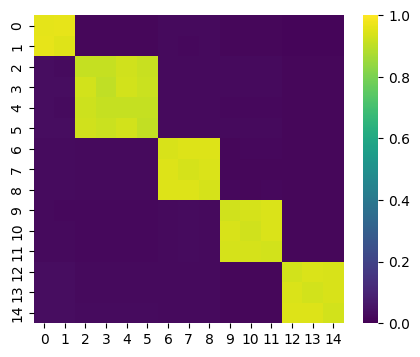

In [30]:
final_matrix = torch.sigmoid(model_dgcn.adj_param).detach().cpu().numpy()
print(final_matrix)
plt.figure(figsize=(5, 4))
sns.heatmap(final_matrix.squeeze(0), cmap="viridis", vmin=0, vmax=1)
plt.show()